# PIZZA SALES ANALYSIS

In [4]:
import pandas as pd
import datetime as dt
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

%matplotlib inline

### Importing Dataset

In [5]:
df = pd.read_csv('pizza_sales.csv')
df.head()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,01-01-2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,01-01-2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,01-01-2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,01-01-2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,01-01-2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [6]:
df.shape

(48620, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pizza_id           48620 non-null  int64  
 1   order_id           48620 non-null  int64  
 2   pizza_name_id      48620 non-null  object 
 3   quantity           48620 non-null  int64  
 4   order_date         48620 non-null  object 
 5   order_time         48620 non-null  object 
 6   unit_price         48620 non-null  float64
 7   total_price        48620 non-null  float64
 8   pizza_size         48620 non-null  object 
 9   pizza_category     48620 non-null  object 
 10  pizza_ingredients  48620 non-null  object 
 11  pizza_name         48620 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 4.5+ MB


### Data Cleaning / Processing

In [8]:
df['order_date'] = pd.to_datetime(df['order_date'],dayfirst=True)
df['order_time'] = pd.to_datetime(df['order_time'])

C:\Users\tanya\AppData\Local\Temp\ipykernel_17940\3558823329.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['order_time'] = pd.to_datetime(df['order_time'])


In [9]:
df['pizza_size'] = df['pizza_size'].astype('category')

In [10]:
# YEAR : 2015
total_revenue = df['total_price'].sum()
total_pizzas_sold = df['quantity'].sum()
total_orders = df['order_id'].nunique()
avg_order_value = total_revenue / total_orders
avg_pizza_per_order = total_pizzas_sold / total_orders

print(f'Total revenue generated : ${total_revenue : ,.2f}')
print(f'Total number of pizzas sold : {total_pizzas_sold}')
print(f'Total number of orders : {total_orders}')
print(f'Average order value(AOV) : ${avg_order_value : ,.2f}')
print(f'Average number of pizza sold per order :{avg_pizza_per_order : ,.2f}')

Total revenue generated : $ 817,860.05
Total number of pizzas sold : 49574
Total number of orders : 21350
Average order value(AOV) : $ 38.31
Average number of pizza sold per order : 2.32


####  Ingredient Analysis
The pizza business aims to understand which ingredients are most frequently used across different pizza types. By identifying the most common ingredients, the store can optimize their inventory management strategies, such that most frequently used items always remain in-stock.

In [11]:
df['pizza_ingredients'].str.split(',').explode().str.strip().value_counts().reset_index()

,pizza_ingredients,count
0,Garlic,27422
1,Tomatoes,26601
2,Red Onions,19547
3,Red Peppers,16284
4,Mozzarella Cheese,10333
...,...,...
60,Brie Carre Cheese,480
61,Prosciutto,480
62,Caramelized Onions,480
63,Pears,480


#### Daily Trend
Total Orders


In [12]:
df.groupby('order_date')['quantity'].sum().reset_index().head()

,order_date,quantity
0,2015-01-01,162
1,2015-01-02,165
2,2015-01-03,158
3,2015-01-04,106
4,2015-01-05,125


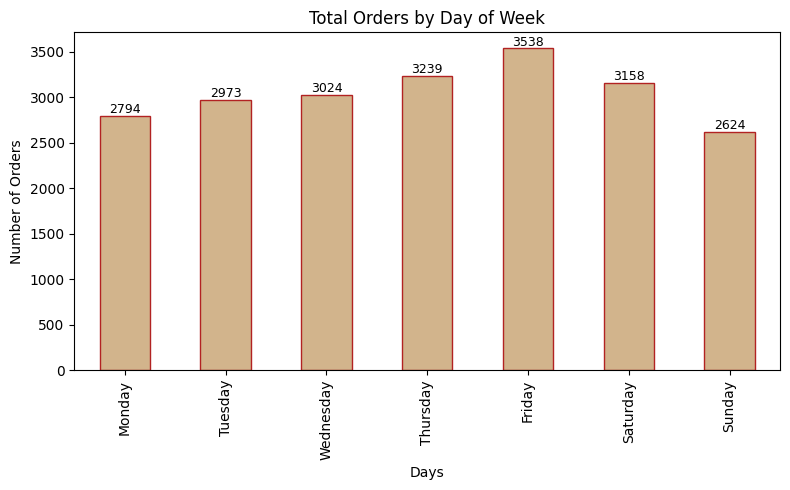

In [13]:
df['order_day'] = df['order_date'].dt.day_name()
weekdays = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['order_day'] = pd.Categorical(df['order_day'],categories = weekdays, ordered=True)
daily_orders = df.groupby('order_day',observed=False)['order_id'].nunique()

ax = daily_orders.plot(kind='bar',figsize=(8,5),color='tan',edgecolor='firebrick')
plt.title('Total Orders by Day of Week')
plt.xlabel('Days')
plt.ylabel('Number of Orders')

for i,val in enumerate(daily_orders):
    plt.text(i,val+30,str(val),ha='center',fontsize=9)

plt.tight_layout()

The data indicates that Friday experiences the highest sales volume, suggesting peak customer demand toward the end of the workweek. Strategic staffing and inventory planning should be prioritized for this day to optimize service efficiency and revenue generation.

Conversely, Sunday shows the lowest number of orders. This trend may be attributed to the store’s proximity to a corporate location, where reduced office activity on weekends likely leads to decreased customer visits.

#### Daily Trend
Total Revenue


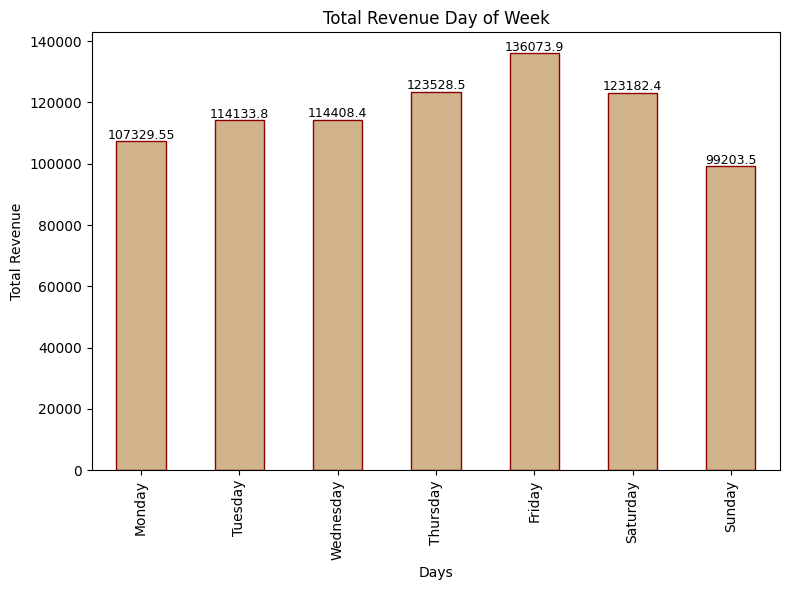

In [14]:
daily_revenue = df.groupby('order_day',observed=False)['total_price'].sum()
ax = daily_revenue.plot(kind='bar',figsize=(8,6),color='tan',edgecolor='darkred')
plt.title('Total Revenue Day of Week')
plt.xlabel('Days')
plt.ylabel('Total Revenue')

for i, val in enumerate(daily_revenue):
    plt.text(i,val+2000,str(val),va='center',ha='center',fontsize=9)
    
plt.tight_layout()

### Hourly Trend
Useful for staffing, ingredients, customer rush and operations planning.

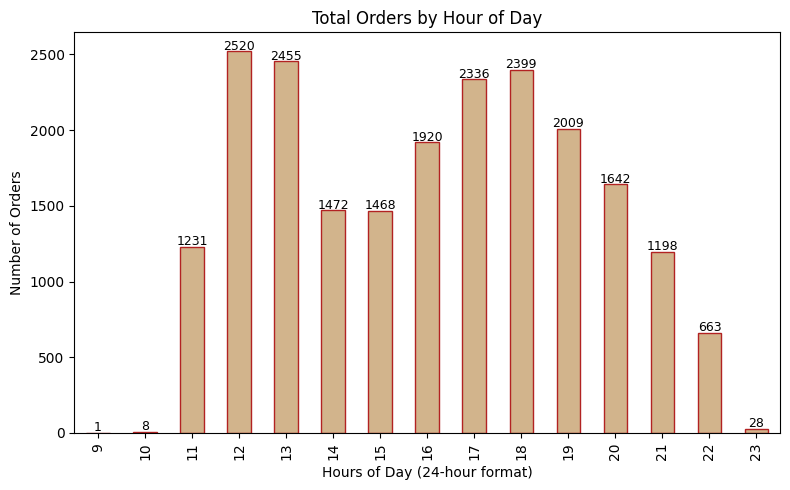

In [15]:
df['order_hour'] = df['order_time'].dt.hour

hourly_orders = df.groupby('order_hour',observed=False)['order_id'].nunique()

ax = hourly_orders.plot(kind='bar',figsize=(8,5),color='tan',edgecolor='firebrick')
plt.title('Total Orders by Hour of Day')
plt.xlabel('Hours of Day (24-hour format)')
plt.ylabel('Number of Orders')

for i,val in enumerate(hourly_orders):
    plt.text(i,val+10,str(val),ha='center',fontsize=9)

plt.tight_layout()

### Monthly Trend

In [16]:
df['order_month'] = df['order_date'].dt.month_name()
monthly_sales = df.groupby('order_month')['total_price'].sum().reset_index().sort_values(by='total_price')
monthly_sales.head()

,order_month,total_price
10,October,64027.60
11,September,64180.05
2,December,64701.15
3,February,65159.60
6,June,68230.20


The revenue shows a noticeable decline during the winter months, particularly around the New Year period. This decrease may be influenced by the holiday season, such as Thanksgiving and other festive periods, when customer purchasing behavior shifts and dining patterns change.

Since demand drops during this time, the business can introduce targeted marketing campaigns, promotional offers, or seasonal discounts during the fall season to offset the expected decline in orders. Proactive strategies such as limited-time festive combos or holiday-themed promotions could help maintain revenue stability during low-demand periods.

### % of Sales by Category

In [17]:
df.groupby('pizza_category')['total_price'].sum() *100.0 / df['total_price'].sum()

pizza_category
Chicken    23.955138
Classic    26.905960
Supreme    25.456311
Veggie     23.682591
Name: total_price, dtype: float64

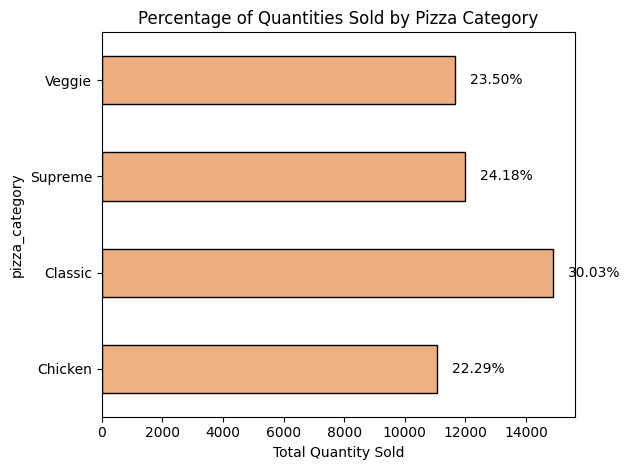

In [50]:
colors = plt.get_cmap('flare').colors
category_data = df.groupby('pizza_category')['quantity'].sum()
total_qty = category_data.sum()

#  Plotting (barh)
ax = category_data.plot(kind='barh', color=colors, edgecolor='black')

#  Manually adding the Percentages to the bars
for i, v in enumerate(category_data):
    percentage = (v / total_qty) * 100
    ax.text(v + (total_qty*0.01), i, f'{percentage:1.2f}%', 
            va='center', color='black')

plt.title('Percentage of Quantities Sold by Pizza Category')
plt.xlabel('Total Quantity Sold')
plt.tight_layout()
plt.show()

The Classic category continues to be the top-selling pizza segment among all categories, consistently generating the highest sales volume. This indicates strong and stable customer preference for traditional flavors.

Given this performance, the company can leverage the popularity of the Classic category by:

>Introducing new seasonal flavors under the Classic segment

>Launching limited-time regional or local-inspired variants

>Testing new flavors through small-scale campaigns

### % Sales by Pizza Size & Category

In [55]:
size_category = pd.crosstab(df['pizza_size'],df['pizza_category'])
size_category = size_category/size_category.sum().sum() *100

<Axes: xlabel='pizza_category', ylabel='pizza_size'>

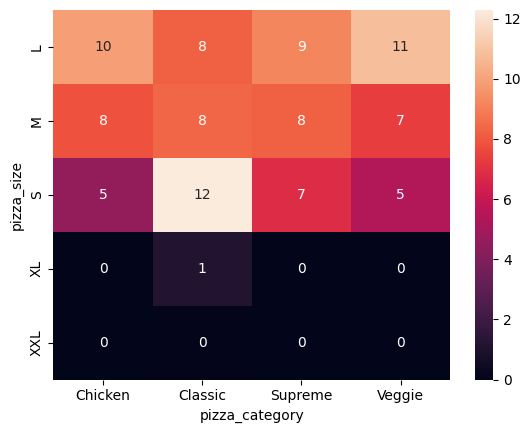

In [56]:
sns.heatmap(size_category,annot=True,fmt='.0f')

The graph indicates that Classic small-size pizzas generate the highest sales among all pizza types and sizes. This trend suggests that many customers, prefer safer and more familiar options rather than experimenting with new flavors. Small-sized pizzas are also likely chosen because they are more affordable and suitable for individual consumption.

To increase customer engagement and encourage product exploration, the business can implement several strategies:

>First-purchase vouchers or bundle offers to encourage customers to buy more than one pizza.

>Combo deals that allow customers to try multiple flavors at a discounted price. Plus launching these orders only on certain days or ceratain hours of a day can act as a great 'pull' stragery.

>_The *Half & Half* Inventory Optimization_
>
>Half-and-half pizzas, where customers can try two flavors in a single pizza, reducing the risk of trying something new.
at the same rate as a standard pizza, you remove the "Choice Penalty."

>End-of-day promotional combos using remaining ingredients to minimize food waste while offering customers unique deals.

These strategies can help increase average order value, encourage experimentation with new flavors, and optimize ingredient utilization, creating a win-win situation for both the business and customers.

### Top 5 Best Selling Pizzas

In [70]:
top5_pizzas = df.groupby(['pizza_name'])[['quantity','total_price']].sum().sort_values(by='total_price',ascending=False).head().reset_index()
top5_pizzas=top5_pizzas.sort_values(by='total_price')
top5_pizzas

,pizza_name,quantity,total_price
4,The Spicy Italian Pizza,1924,34831.25
3,The Classic Deluxe Pizza,2453,38180.50
2,The California Chicken Pizza,2370,41409.50
1,The Barbecue Chicken Pizza,2432,42768.00
0,The Thai Chicken Pizza,2371,43434.25


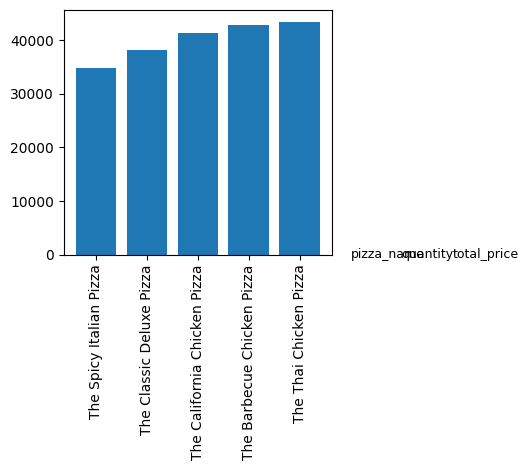

In [71]:
plt.bar(top5_pizzas['pizza_name'],top5_pizzas['total_price'])
for i,val in enumerate (top5_pizzas):
    plt.text(val,i,str(val),va='center',fontsize=9)

plt.xticks(rotation=90)
plt.tight_layout()

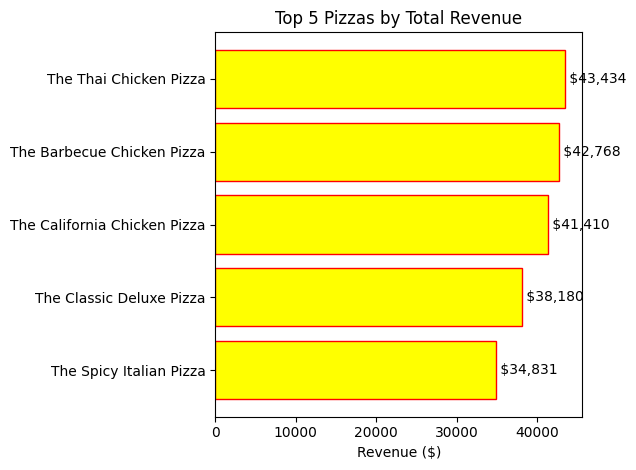

In [91]:
plt.barh(top5_pizzas['pizza_name'], top5_pizzas['total_price'], color='yellow', edgecolor='red')
# Add Labels to the Right of the Bars
for i in range(len(top5_pizzas)):
    value = top5_pizzas['total_price'].iloc[i]
    label = f" ${value:,.0f}" 
    
    # x = the value (end of the bar)
    # y = i (the vertical position)
    plt.text(x = value, 
             y = i, 
             s = label, 
             va = 'center',   
             ha = 'left',     
             fontsize = 10)

plt.title('Top 5 Pizzas by Total Revenue')
plt.xlabel('Revenue ($)')
plt.tight_layout()
plt.show()